# Import Libraries

In [1]:
import os
import re
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import (train_test_split, 
                                     cross_val_score, 
                                     GridSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (StandardScaler, 
                                   TargetEncoder, 
                                   FunctionTransformer)
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.ensemble import (GradientBoostingRegressor, 
                              BaggingRegressor, 
                              HistGradientBoostingRegressor, 
                              RandomForestRegressor)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR  
from xgboost import XGBRegressor 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# Load Dataset

In [2]:
def download_document(file_name, document_url):
    if os.path.exists(file_name):
        pass
    else:
        response = requests.get(document_url)
        if response.status_code == 200:
            with open(file_name, 'wb') as f:
                f.write(response.content)
        else:
            print(f'Failed to download the document. Status code: {response.status_code}')

file_name = 'ikea.csv'
document_url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-11-03/ikea.csv'
download_document(file_name, document_url)

# Exploratory Data Analysis (EDA)

In [3]:
df = pd.read_csv('ikea.csv')
df.head()

,Unnamed: 0,item_id,name,category,price,old_price,sellable_online,link,other_colors,short_description,designer,depth,height,width
0,0,90420332,FREKVENS,Bar furniture,265.0,No old price,True,https://www.ikea.com/sa/en/p/frekvens-bar-tabl...,No,"Bar table, in/outdoor, 51x51 cm",Nicholai Wiig Hansen,NaN,99.0,51.0
1,1,368814,NORDVIKEN,Bar furniture,995.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-bar-tab...,No,"Bar table, 140x80 cm",Francis Cayouette,NaN,105.0,80.0
2,2,9333523,NORDVIKEN / NORDVIKEN,Bar furniture,2095.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-nordvik...,No,Bar table and 4 bar stools,Francis Cayouette,NaN,NaN,NaN
3,3,80155205,STIG,Bar furniture,69.0,No old price,True,https://www.ikea.com/sa/en/p/stig-bar-stool-wi...,Yes,"Bar stool with backrest, 74 cm",Henrik Preutz,50.0,100.0,60.0
4,4,30180504,NORBERG,Bar furniture,225.0,No old price,True,https://www.ikea.com/sa/en/p/norberg-wall-moun...,No,"Wall-mounted drop-leaf table, ...",Marcus Arvonen,60.0,43.0,74.0


In [4]:
df = df.drop(columns=['Unnamed: 0'])

In [5]:
df.describe()

,item_id,price,depth,height,width
count,3.694000e+03,3694.000000,2231.000000,2706.000000,3105.000000
mean,4.863240e+07,1078.208419,54.379202,101.679970,104.470853
std,2.888709e+07,1374.652494,29.958351,61.097585,71.133771
min,5.848700e+04,3.000000,1.000000,1.000000,1.000000
25%,2.039057e+07,180.900000,38.000000,67.000000,60.000000
50%,4.928808e+07,544.700000,47.000000,83.000000,80.000000
75%,7.040357e+07,1429.500000,60.000000,124.000000,140.000000
max,9.993262e+07,9585.000000,257.000000,700.000000,420.000000


In [6]:
df.shape

(3694, 13)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3694 entries, 0 to 3693
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   item_id            3694 non-null   int64  
 1   name               3694 non-null   object 
 2   category           3694 non-null   object 
 3   price              3694 non-null   float64
 4   old_price          3694 non-null   object 
 5   sellable_online    3694 non-null   bool   
 6   link               3694 non-null   object 
 7   other_colors       3694 non-null   object 
 8   short_description  3694 non-null   object 
 9   designer           3694 non-null   object 
 10  depth              2231 non-null   float64
 11  height             2706 non-null   float64
 12  width              3105 non-null   float64
dtypes: bool(1), float64(4), int64(1), object(7)
memory usage: 350.0+ KB


In [8]:
df.isnull().sum()

item_id                 0
name                    0
category                0
price                   0
old_price               0
sellable_online         0
link                    0
other_colors            0
short_description       0
designer                0
depth                1463
height                988
width                 589
dtype: int64

In [9]:
df.isnull().sum() * 100 / len(df)

item_id               0.000000
name                  0.000000
category              0.000000
price                 0.000000
old_price             0.000000
sellable_online       0.000000
link                  0.000000
other_colors          0.000000
short_description     0.000000
designer              0.000000
depth                39.604764
height               26.746075
width                15.944775
dtype: float64

In [10]:
df.columns

Index(['item_id', 'name', 'category', 'price', 'old_price', 'sellable_online',
       'link', 'other_colors', 'short_description', 'designer', 'depth',
       'height', 'width'],
      dtype='object')

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
print(df.nunique().to_markdown())

|                   |    0 |
|:------------------|-----:|
| item_id           | 2962 |
| name              |  607 |
| category          |   17 |
| price             |  979 |
| old_price         |  365 |
| sellable_online   |    2 |
| link              | 2962 |
| other_colors      |    2 |
| short_description | 1706 |
| designer          |  381 |
| depth             |  114 |
| height            |  193 |
| width             |  263 |


In [13]:
df.duplicated(subset=['item_id']).sum()

np.int64(732)

In [14]:
df[df["item_id"].duplicated(keep=False)].sort_values(by="item_id")

,item_id,name,category,price,old_price,sellable_online,link,other_colors,short_description,designer,depth,height,width
1918,91415,TROFAST,Nursery furniture,5.0,No old price,True,https://www.ikea.com/sa/en/p/trofast-lid-white...,No,"Lid, 20x28 cm",Studio Copenhagen,NaN,NaN,28.0
1834,91415,TROFAST,Children's furniture,5.0,No old price,True,https://www.ikea.com/sa/en/p/trofast-lid-white...,No,"Lid, 20x28 cm",Studio Copenhagen,NaN,NaN,28.0
2560,102065,LYCKSELE LÖVÅS,Sofas & armchairs,495.0,No old price,True,https://www.ikea.com/sa/en/p/lycksele-loevas-m...,No,"Mattress, 140x188 cm",IKEA of Sweden,NaN,NaN,NaN
151,102065,LYCKSELE LÖVÅS,Beds,495.0,No old price,True,https://www.ikea.com/sa/en/p/lycksele-loevas-m...,No,"Mattress, 140x188 cm",IKEA of Sweden,NaN,NaN,NaN
2178,105064,LIATORP,"Sideboards, buffets & console tables",445.0,No old price,True,https://www.ikea.com/sa/en/p/liatorp-console-t...,No,"Console table, 133x37 cm",Carina Bengs,NaN,75.0,37.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2860,99323614,SMÅGÖRA,Tables & desks,370.0,No old price,True,https://www.ikea.com/sa/en/p/smagoera-changing...,No,Changing tbl/bookshelf w 1 shlf ut,IKEA of Sweden,40.0,91.0,60.0
29,99323925,STENSELE,Bar furniture,550.0,No old price,True,https://www.ikea.com/sa/en/p/stensele-bar-tabl...,No,"Bar table, 70x70 cm",Maja Ganszyniec,NaN,104.0,70.0
3028,99323925,STENSELE,Tables & desks,550.0,No old price,True,https://www.ikea.com/sa/en/p/stensele-bar-tabl...,No,"Bar table, 70x70 cm",Maja Ganszyniec,NaN,104.0,70.0
409,99902661,VITTSJÖ,Bookcases & shelving units,609.0,No old price,True,https://www.ikea.com/sa/en/p/vittsjoe-shelving...,No,"Shelving unit with laptop table, ...",Johan Kroon,36.0,NaN,202.0


# Data Cleaning & Data Visualization

In [15]:
df_base = df.copy()

In [16]:
df_base = df_base.drop_duplicates(subset=['item_id']).reset_index(drop=True)
df_base.drop(columns=['link'], inplace=True)

In [17]:
df_base.duplicated(subset=['item_id']).sum()

np.int64(0)

In [18]:
df_base.drop(columns=['item_id'], inplace=True)

In [19]:
df_base.head()

,name,category,price,old_price,sellable_online,other_colors,short_description,designer,depth,height,width
0,FREKVENS,Bar furniture,265.0,No old price,True,No,"Bar table, in/outdoor, 51x51 cm",Nicholai Wiig Hansen,NaN,99.0,51.0
1,NORDVIKEN,Bar furniture,995.0,No old price,False,No,"Bar table, 140x80 cm",Francis Cayouette,NaN,105.0,80.0
2,NORDVIKEN / NORDVIKEN,Bar furniture,2095.0,No old price,False,No,Bar table and 4 bar stools,Francis Cayouette,NaN,NaN,NaN
3,STIG,Bar furniture,69.0,No old price,True,Yes,"Bar stool with backrest, 74 cm",Henrik Preutz,50.0,100.0,60.0
4,NORBERG,Bar furniture,225.0,No old price,True,No,"Wall-mounted drop-leaf table, ...",Marcus Arvonen,60.0,43.0,74.0


In [20]:
print(df_base["category"].value_counts().to_markdown())        

| category                             |   count |
|:-------------------------------------|--------:|
| Bookcases & shelving units           |     548 |
| Chairs                               |     438 |
| Sofas & armchairs                    |     380 |
| Tables & desks                       |     370 |
| Wardrobes                            |     220 |
| Beds                                 |     208 |
| Outdoor furniture                    |     197 |
| Cabinets & cupboards                 |     187 |
| Chests of drawers & drawer units     |     111 |
| TV & media furniture                 |      89 |
| Children's furniture                 |      84 |
| Bar furniture                        |      47 |
| Trolleys                             |      23 |
| Nursery furniture                    |      22 |
| Café furniture                       |      18 |
| Sideboards, buffets & console tables |      10 |
| Room dividers                        |      10 |


C:\Users\Anna\AppData\Local\Temp\ipykernel_6304\253227387.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_base, y='category', order=order, palette='viridis')


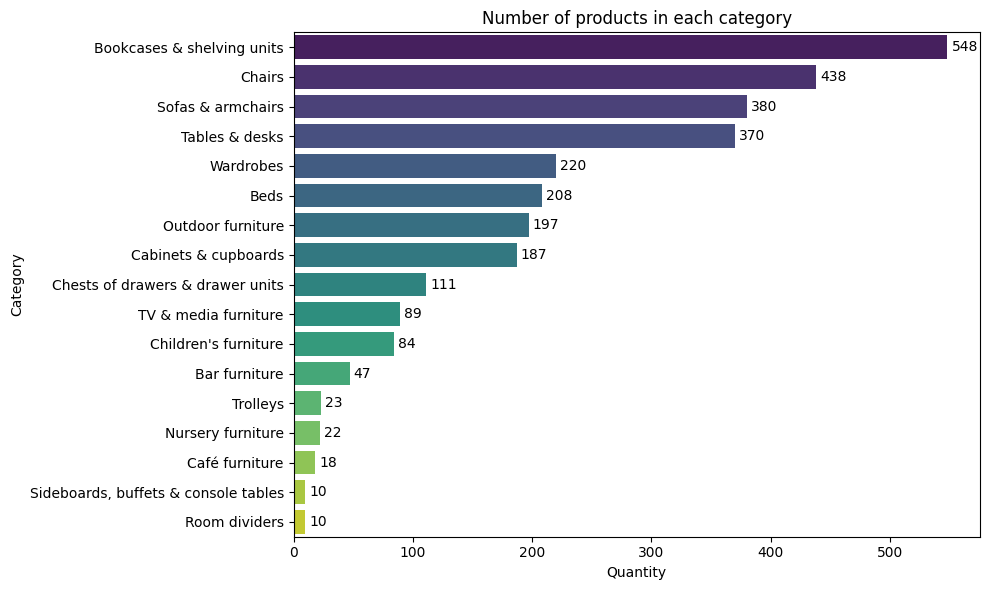

In [21]:
plt.figure(figsize=(10, 6))
order = df_base['category'].value_counts().index
ax = sns.countplot(data=df_base, y='category', order=order, palette='viridis')  

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Number of products in each category')
plt.xlabel('Quantity') 
plt.ylabel('Category')
plt.tight_layout() 
plt.show()


In [22]:
print((df_base.groupby('category')['price'].median().sort_values(ascending=False)).to_markdown())

| category                             |   price |
|:-------------------------------------|--------:|
| Wardrobes                            |  1950   |
| Sofas & armchairs                    |  1157   |
| Beds                                 |  1093.5 |
| Sideboards, buffets & console tables |   927.5 |
| TV & media furniture                 |   860   |
| Cabinets & cupboards                 |   845   |
| Room dividers                        |   595   |
| Trolleys                             |   537   |
| Chests of drawers & drawer units     |   499   |
| Chairs                               |   497   |
| Tables & desks                       |   475   |
| Bar furniture                        |   445   |
| Café furniture                       |   370   |
| Outdoor furniture                    |   345   |
| Nursery furniture                    |   322.5 |
| Bookcases & shelving units           |   310   |
| Children's furniture                 |   202.5 |


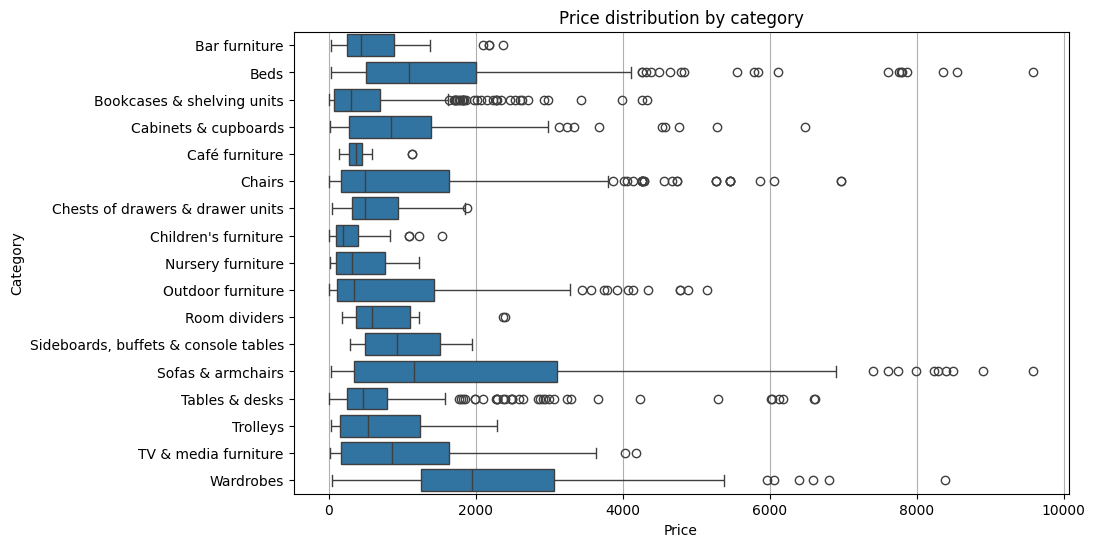

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_base, x='price', y='category')
plt.title('Price distribution by category') 
plt.xlabel('Price')
plt.ylabel('Category')
plt.grid(axis='x') 
plt.show()

Having conducted a quantitative and price analysis of products by category, we can see that the categories Bookcases & Shelving units, Chairs, Sofas & armchairs, and Tables & desks predominate in quantity. The most expensive categories are 'Wardrobes', 'Sofas & armchairs', and 'Beds'.

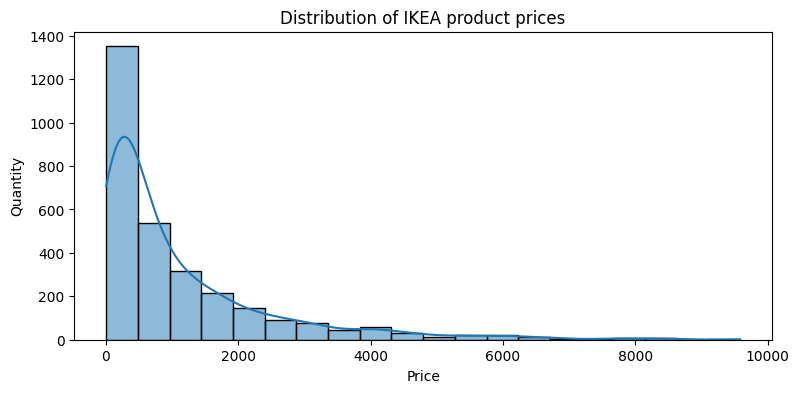

In [24]:
plt.figure(figsize=(9,4))
sns.histplot(df_base['price'], kde=True, bins=20)
plt.title('Distribution of IKEA product prices')
plt.xlabel('Price')
plt.ylabel('Quantity') 
plt.show()

We can see that the price distribution is heavily right-skewed (positive skew). Most IKEA furniture costs under 2,000 units, but there are isolated items priced above 8,000. This means that the mean price will be higher than the median.Since the high prices represent real market data for certain categories (for example, wardrobes), I decided not to remove them so that the model can recognize expensive segments.

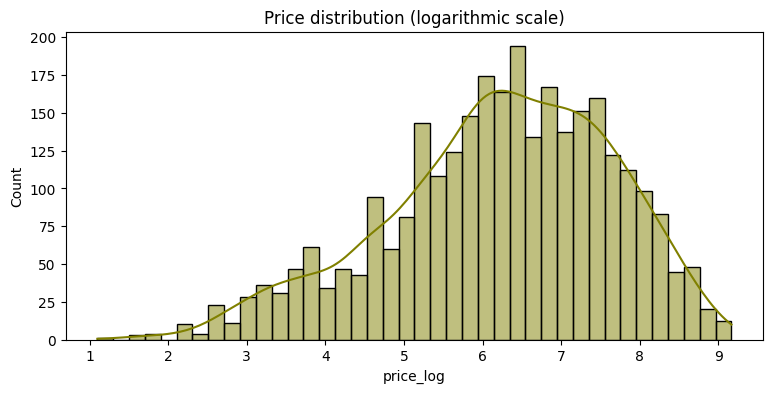

In [25]:
plt.figure(figsize=(9, 4))
df_base['price_log'] = np.log(df_base['price']) 
sns.histplot(df_base['price_log'], kde=True, binwidth=0.2, color='olive')
plt.title('Price distribution (logarithmic scale)')
plt.show()

To stabilize the variance and bring the distribution of the target variable closer to normal, a log-transformation was applied. This helps reduce the impact of price outliers and improves the quality of the future predictive model.

In [26]:
df_base['sellable_online'].value_counts(normalize=True)                                         

sellable_online
True     0.993585
False    0.006415
Name: proportion, dtype: float64

C:\Users\Anna\AppData\Local\Temp\ipykernel_6304\427419664.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_base, x='sellable_online', palette='viridis')


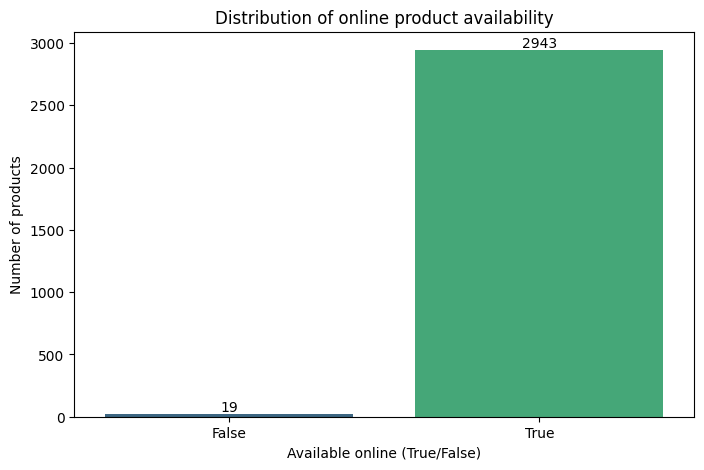

In [27]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_base, x='sellable_online', palette='viridis')
for i in ax.containers:
    ax.bar_label(i)
plt.title('Distribution of online product availability')
plt.xlabel('Available online (True/False)')
plt.ylabel('Number of products') 
plt.show()

Analysis of the sellable_online column showed that over 99% of products are available for online ordering. Due to the lack of variance, this feature carries no informative value for building predictive models and can be removed from further consideration.

In [28]:
df_base.drop(columns=['sellable_online'], inplace=True)

In [29]:
df_base['other_colors'].value_counts(normalize=True) 

other_colors
No     0.552667
Yes    0.447333
Name: proportion, dtype: float64

C:\Users\Anna\AppData\Local\Temp\ipykernel_6304\688224755.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_base, x='other_colors', palette='Blues', edgecolor='black')


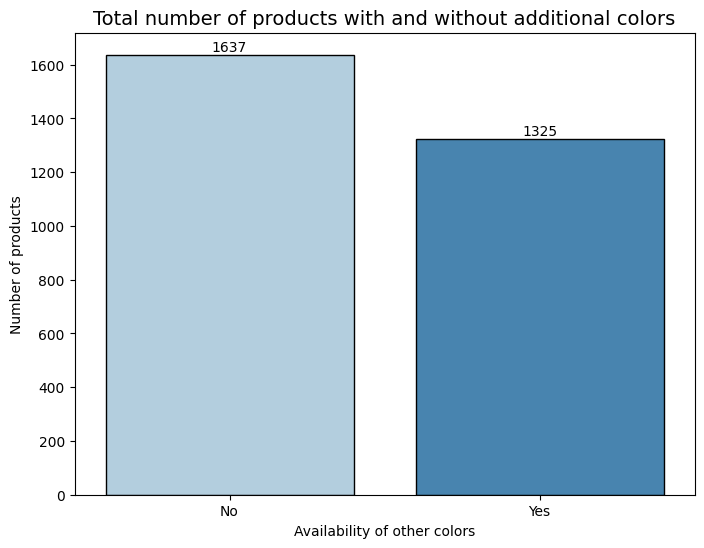

In [30]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df_base, x='other_colors', palette='Blues', edgecolor='black')
for i in ax.containers:
    ax.bar_label(i)
plt.title('Total number of products with and without additional colors', fontsize=14)
plt.xlabel('Availability of other colors')
plt.ylabel('Number of products') # Or 'Product count'
plt.show()

C:\Users\Anna\AppData\Local\Temp\ipykernel_6304\2802269608.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_price = sns.barplot(data=price_median, x='other_colors', y='price', palette='magma', edgecolor='black')


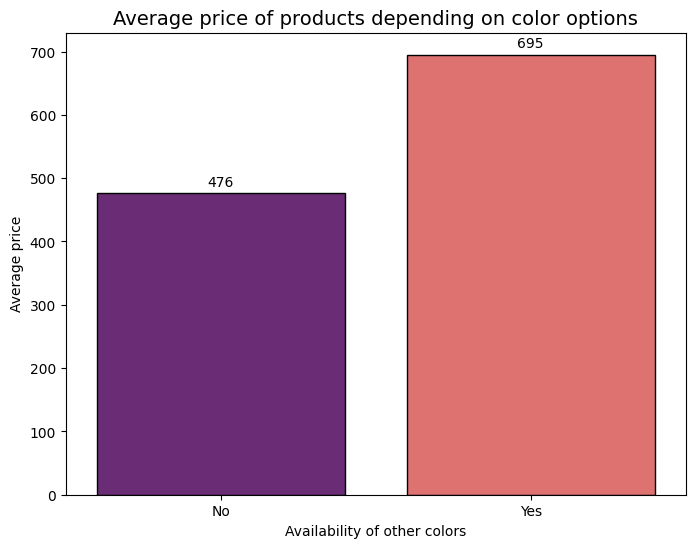

In [31]:
plt.figure(figsize=(8, 6))
price_median = df_base.groupby('other_colors')['price'].median().reset_index()
ax_price = sns.barplot(data=price_median, x='other_colors', y='price', palette='magma', edgecolor='black')
for i in ax_price.containers:
    ax_price.bar_label(i, fmt='%.0f', padding=3)
plt.title('Average price of products depending on color options', fontsize=14)
plt.xlabel('Availability of other colors')
plt.ylabel('Average price')
plt.show()

Price gap: The average price of products with additional colors (745) is 50% higher than that of products without them (495). This is a statistical fact within this dataset.Catalog distribution: Products without additional colors make up the majority of the assortment (55%), but the group with colors is also significant (45%).

In [32]:
df_base['designer'].unique()

array(['Nicholai Wiig Hansen', 'Francis Cayouette', 'Henrik Preutz',
       'Marcus Arvonen', 'Carina Bengs', 'K Hagberg/M Hagberg',
       'Sarah Fager', 'Ehlén Johansson', 'Nike Karlsson',
       'Maja Ganszyniec', 'Karl Malmvall',
       'John/Jonas/Petrus/Paul/Caroline', 'Nike Karlsson/Maja Ganszyniec',
       'J Karlsson/N Karlsson', 'IKEA of Sweden/Karl Malmvall',
       'IKEA of Sweden', 'Nike Karlsson/J Karlsson/N Karlsson',
       'Ola Wihlborg', 'IKEA of Sweden/Tina Christensen',
       'IKEA of Sweden/K Hagberg/M Hagberg',
       'Ola Wihlborg/IKEA of Sweden',
       '504.689.53 Small and easy-to-place chair-bed which can easily be converted into a single bed.The storage space under the seat has room for bedlinen or other things.Just as nice to look at from all sides – perfect to place in the middle of the room or use as a room divider.The cushion cover is easy to keep clean and fresh, as you can take it off and machine-wash it.Easy to assemble.1 cushion included.',
       '

In [33]:
mask = ~df_base["designer"].str.contains(r'\d', na=False)
df_base = df_base.loc[mask].copy()

In [34]:
df_base.loc[:, 'designer'] = df_base['designer'].str.replace(r'K Hagberg\s*/\s*M Hagberg', 'Hagberg family',regex=True)

In [35]:
df_base['designer'].unique()

array(['Nicholai Wiig Hansen', 'Francis Cayouette', 'Henrik Preutz',
       'Marcus Arvonen', 'Carina Bengs', 'Hagberg family', 'Sarah Fager',
       'Ehlén Johansson', 'Nike Karlsson', 'Maja Ganszyniec',
       'Karl Malmvall', 'John/Jonas/Petrus/Paul/Caroline',
       'Nike Karlsson/Maja Ganszyniec', 'J Karlsson/N Karlsson',
       'IKEA of Sweden/Karl Malmvall', 'IKEA of Sweden',
       'Nike Karlsson/J Karlsson/N Karlsson', 'Ola Wihlborg',
       'IKEA of Sweden/Tina Christensen', 'IKEA of Sweden/Hagberg family',
       'Ola Wihlborg/IKEA of Sweden', 'IKEA of Sweden/Ebba Strandmark',
       'Hagberg family/IKEA of Sweden', 'Jon Karlsson',
       'IKEA of Sweden/Carina Bengs', 'David Wahl',
       'Jon Karlsson/IKEA of Sweden', 'IKEA of Sweden/Paulin Machado',
       'IKEA of Sweden/Eva Lilja Löwenhielm',
       'IKEA of Sweden/Synnöve Mork/Ola Wihlborg',
       'IKEA of Sweden/David Wahl', 'Ebba Strandmark/IKEA of Sweden',
       'Eva Lilja Löwenhielm', 'IKEA of Sweden/Anna Efverlu

In [36]:
def clean_designer_final(text):
    if pd.isna(text):
        return "Unknown"
    parts = re.split(r'[/,]| \band\b ', text)
    
    parts = [p.strip() for p in parts if p.strip()]
    
    if len(parts) > 1 and "IKEA of Sweden" in parts:
        parts.remove("IKEA of Sweden")

    if not parts:
        return "IKEA of Sweden"
    
    if parts[0] == "John":
        return "IKEA Team"
        
    return parts[0]

df_base['designer_cleaned'] = df_base['designer'].apply(clean_designer_final)


In [37]:
print(df_base['designer_cleaned'].value_counts().head(15).to_markdown())  

| designer_cleaned     |   count |
|:---------------------|--------:|
| IKEA of Sweden       |     683 |
| Ehlén Johansson      |     310 |
| Ola Wihlborg         |     174 |
| Francis Cayouette    |     168 |
| Jon Karlsson         |     155 |
| Hagberg family       |     134 |
| Ebba Strandmark      |      83 |
| Henrik Preutz        |      78 |
| Eva Lilja Löwenhielm |      75 |
| Carina Bengs         |      71 |
| K Malmvall           |      55 |
| Nike Karlsson        |      55 |
| Marcus Arvonen       |      52 |
| Tord Björklund       |      46 |
| David Wahl           |      46 |


In [38]:
sorted_designers= sorted(df_base['designer_cleaned'].unique().astype(str))
for name in sorted_designers:
    print(name)  

A Fredriksson
A Huldén
Andreas Fredriksson
Anna Efverlund
Anna Palleschitz
Annie Huldén
C Halskov
C Styrbjörn
Carina Bengs
Carl Öjerstam
Charlie Styrbjörn
Chenyi Ke
Chris Martin
David Wahl
E Strandmark
E Thomasson
Ebba Strandmark
Ehlén Johansson
Elizabet Gutierrez
Eva Lilja Löwenhielm
Eva Schildt
Francis Cayouette
Fredriksson
Gillis Lundgren
Gustav Carlberg
H Preutz
HAY
Hagberg family
Henrik Preutz
IKEA Team
IKEA of Sweden
J Asshoff
J Fritzdorf
J Karlsson
J Löfgren
Johan Kroon
Johanna Asshoff
Johanna Jelinek
Jomi Evers
Jon Karlsson
Jonas Hultqvist
Jooyeon Lee
K Malmvall
Karl Malmvall
L Hilland
Lars Norinder
Lisa Hilland
Lisa Norinder
Lisel Garsveden
Lycke von Schantz
M Kjelstrup
Magnus Elebäck
Maja Ganszyniec
Malin Unnborn
Marcus Arvonen
Maria Vinka
Mia Lagerman
Mikael Axelsson
Mikael Warnhammar
Monika Mulder
Nada Debs
Nicholai Wiig Hansen
Niels Gammelgaard
Nike Karlsson
Noboru Nakamura
Ola Wihlborg
Olle Lundberg
P Süssmann
Paulin Machado
S Edholm
S Fager
S Holmbäck
S Lanneskog
Sarah F

In [39]:
final_name_fixer = {
    'A Fredriksson': 'Andreas Fredriksson',
    'A Huldén': 'Annie Huldén',
    'C Styrbjörn': 'Charlie Styrbjörn',
    'E Strandmark': 'Ebba Strandmark',
    'E Lilja Löwenhielm': 'Eva Lilja Löwenhielm',                                                   
    'Fredriksson': 'Andreas Fredriksson',
    'Hilland': 'Lisa Hilland',
    'H Preutz': 'Henrik Preutz',
    'J Asshoff': 'Johanna Asshoff',
    'J Hultqvist': 'Jonas Hultqvist',
    'J Jelinek': 'Johanna Jelinek',
    'J Karlsson': 'Jon Karlsson',
    'K Malmvall': 'Karl Malmvall',
    'L Löwenhielm': 'Eva Lilja Löwenhielm',
    'L Hilland': 'Lisa Hilland',
    'M Axelsson': 'Mikael Axelsson',
    'S Fager': 'Sarah Fager',
    'T Christensen': 'Tina Christensen',
    'N Karlsson': 'Nike Karlsson'
}


df_base['designer_final'] = df_base['designer_cleaned'].map(lambda x: final_name_fixer.get(x, x))


In [40]:
sort_des_rep = sorted(df_base['designer_final'].unique().astype(str))
for name in sort_des_rep:
    print(name)

Andreas Fredriksson
Anna Efverlund
Anna Palleschitz
Annie Huldén
C Halskov
Carina Bengs
Carl Öjerstam
Charlie Styrbjörn
Chenyi Ke
Chris Martin
David Wahl
E Thomasson
Ebba Strandmark
Ehlén Johansson
Elizabet Gutierrez
Eva Lilja Löwenhielm
Eva Schildt
Francis Cayouette
Gillis Lundgren
Gustav Carlberg
HAY
Hagberg family
Henrik Preutz
IKEA Team
IKEA of Sweden
J Fritzdorf
J Löfgren
Johan Kroon
Johanna Asshoff
Johanna Jelinek
Jomi Evers
Jon Karlsson
Jonas Hultqvist
Jooyeon Lee
Karl Malmvall
Lars Norinder
Lisa Hilland
Lisa Norinder
Lisel Garsveden
Lycke von Schantz
M Kjelstrup
Magnus Elebäck
Maja Ganszyniec
Malin Unnborn
Marcus Arvonen
Maria Vinka
Mia Lagerman
Mikael Axelsson
Mikael Warnhammar
Monika Mulder
Nada Debs
Nicholai Wiig Hansen
Niels Gammelgaard
Nike Karlsson
Noboru Nakamura
Ola Wihlborg
Olle Lundberg
P Süssmann
Paulin Machado
S Edholm
S Holmbäck
S Lanneskog
Sarah Fager
Studio Copenhagen
Synnöve Mork
T Winkel
Thomas Sandell
Tina Christensen
Tom Dixon
Tord Björklund
Virgil Abloh
Wieb

In [41]:
print(df_base['designer_final'].value_counts().head(15).to_markdown())

| designer_final       |   count |
|:---------------------|--------:|
| IKEA of Sweden       |     683 |
| Ehlén Johansson      |     310 |
| Ola Wihlborg         |     174 |
| Jon Karlsson         |     169 |
| Francis Cayouette    |     168 |
| Hagberg family       |     134 |
| Henrik Preutz        |     110 |
| Ebba Strandmark      |      87 |
| Eva Lilja Löwenhielm |      75 |
| Carina Bengs         |      71 |
| Karl Malmvall        |      60 |
| Nike Karlsson        |      55 |
| Marcus Arvonen       |      52 |
| Andreas Fredriksson  |      51 |
| Tord Björklund       |      46 |


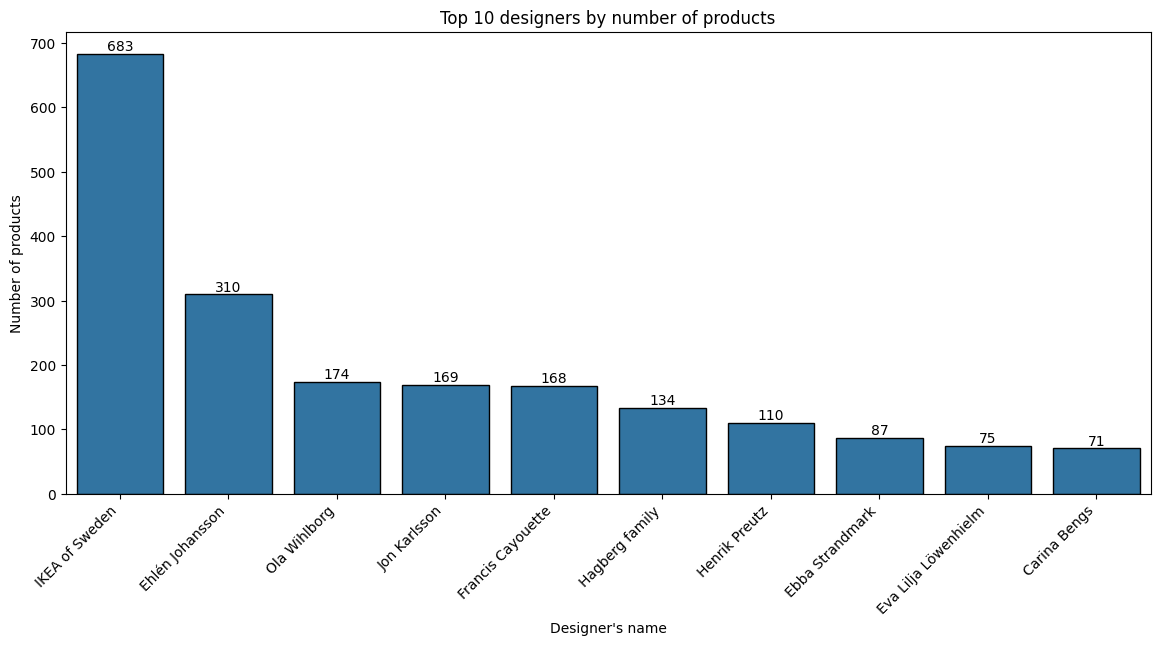

In [42]:
plt.figure(figsize=(14, 6))
top_designer = df_base['designer_final'].value_counts().nlargest(10).reset_index()
top_designer.columns = ['designer_final', 'product_count']
barplot = sns.barplot(data=top_designer, x='designer_final', y='product_count', edgecolor='black')
for i in barplot.containers:
    barplot.bar_label(i)
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 designers by number of products")
plt.xlabel("Designer's name")
plt.ylabel("Number of products") 
plt.show()

Найбільший внесок в асортимент робить команда IKEA of Sweden (683 унікальні позиції). Серед індивідуальних авторів найпродуктивнішими є Ehlén Johansson та Ola Wihlborg.

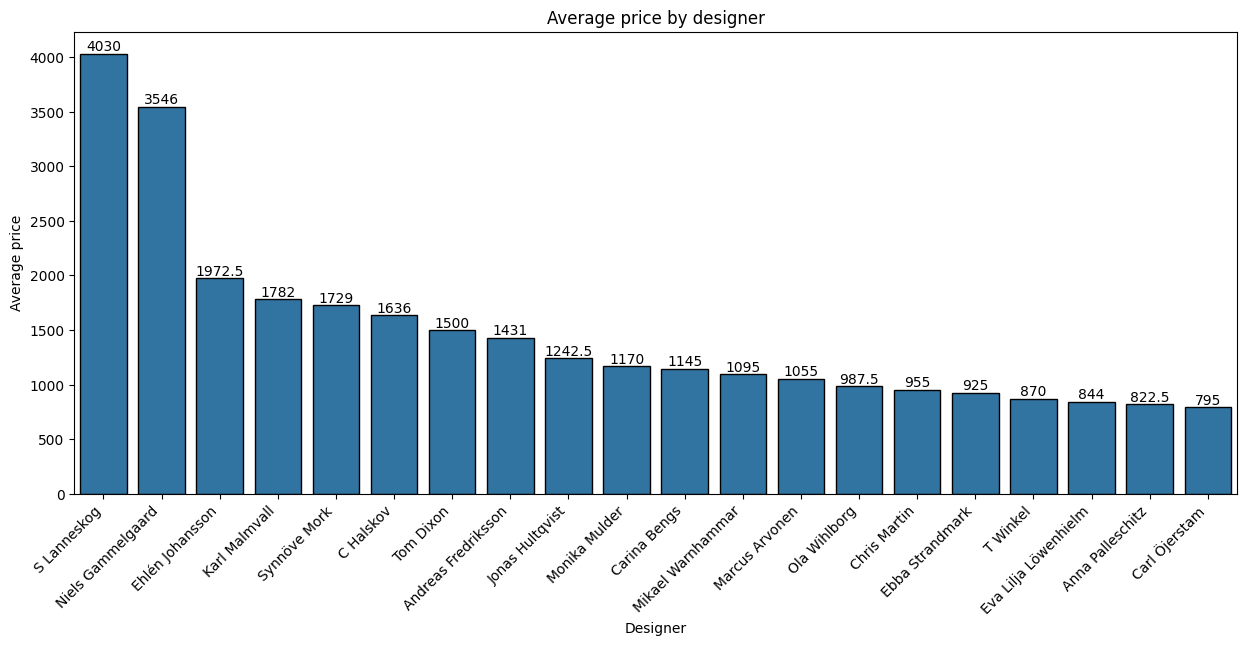

In [43]:
plt.figure(figsize=(15, 6))
designer_price = df_base.groupby('designer_final')['price'].median().nlargest(20).reset_index()
designer_price_plot = sns.barplot(data=designer_price, x='designer_final', y='price', edgecolor='black')
for i in designer_price_plot.containers:
    designer_price_plot.bar_label(i)
plt.title('Average price by designer')
plt.xlabel('Designer')
plt.ylabel('Average price')
plt.xticks(rotation=45, ha='right')
plt.show()

The visualization confirmed significant price variance depending on authorship. A 'premium' segment of designers was identified (for example, S Lanneskog with an average price > 4,000 and Niels Gammelgaard > 3,000), making the designer column critically important for price forecasting.

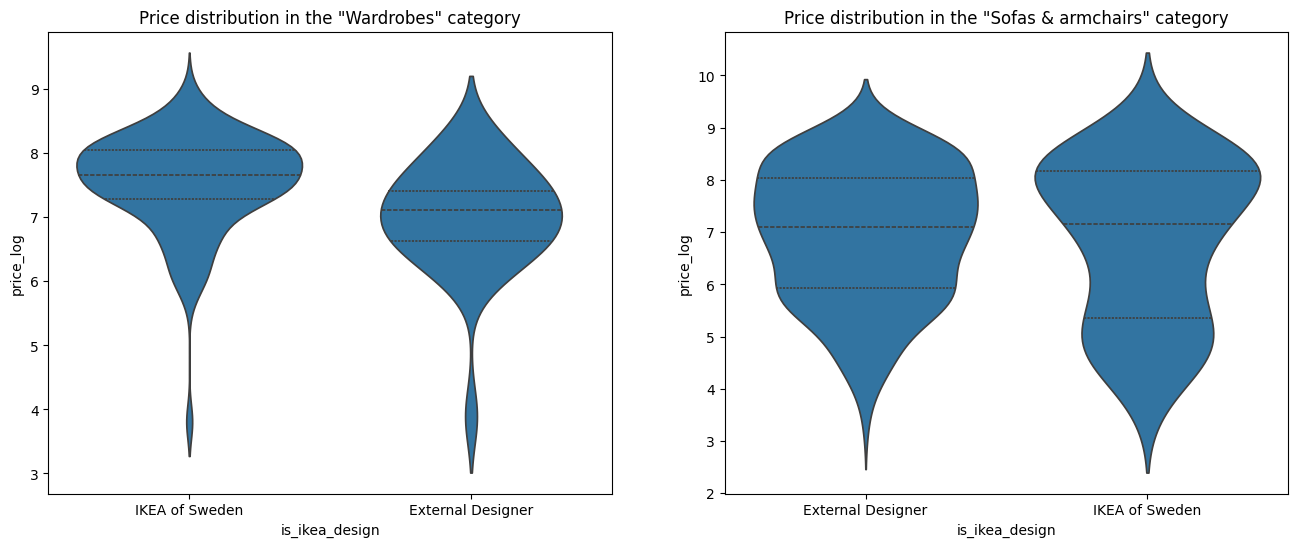

In [44]:
df_base['is_ikea_design'] = df_base['designer'].apply(
    lambda x: 'IKEA of Sweden' if 'IKEA of Sweden' in str(x) else 'External Designer'
)
plt.figure(figsize=(16, 6)) 

plt.subplot(1, 2, 1) 
top_category_1 = 'Wardrobes'
category_df_1 = df_base[df_base['category'] == top_category_1]
sns.violinplot(x='is_ikea_design', y='price_log', data=category_df_1, inner="quart")
plt.title(f'Price distribution in the "{top_category_1}" category')


plt.subplot(1, 2, 2) 
top_category_2 = 'Sofas & armchairs'
category_df_2 = df_base[df_base['category'] == top_category_2]
sns.violinplot(x='is_ikea_design', y='price_log', data=category_df_2, inner="quart")
plt.title(f'Price distribution in the "{top_category_2}" category')

plt.show() 

In [45]:
print(df_base[['width', 'height', 'depth']].isnull().sum().to_markdown())   

|        |    0 |
|:-------|-----:|
| width  |  414 |
| height |  695 |
| depth  | 1062 |


In [46]:
for col in ['depth', 'height', 'width']:
    df_base[col] = df_base[col].fillna(df_base.groupby('category')[col].transform('median'))

In [47]:
print(df_base[['width', 'height', 'depth']].isnull().sum().to_markdown()) 

|        |   0 |
|:-------|----:|
| width  |   0 |
| height |   0 |
| depth  |   0 |


In [48]:
df_base['volume'] = df_base['width'] * df_base['height'] * df_base['depth']

Text(0.5, 1.0, "Spearman's rank correlation: price and size")

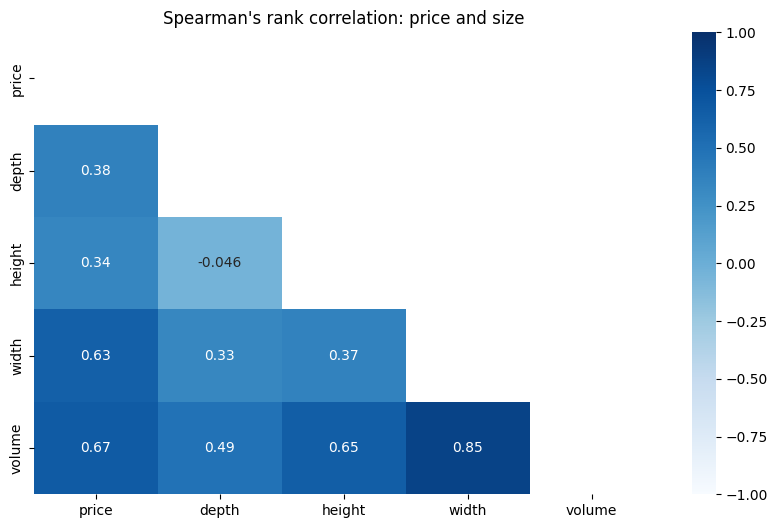

In [49]:
plt.figure(figsize=(10, 6))
correlation_spearman = df_base[['price', 'depth', 'height', 'width', 'volume']].corr(method='spearman')
mask = np.triu(np.ones_like(correlation_spearman, dtype=bool))
sns.heatmap(correlation_spearman, annot=True, mask=mask, cmap='Blues', vmin=-1, vmax=1)
plt.title("Spearman's rank correlation: price and size") 

Correlation analysis confirmed that product dimensions are significant predictors of price. The highest level of correlation is observed between width and cost (r = 0.63). The low interdependence between the dimensions themselves (ranging from -0.046 to 0.37) indicates an absence of multicollinearity, allowing all three dimensions to be used as independent features in the machine learning model.

Hypothesis №1: Designer's Impact on PriceFormulation: The designer significantly influences the pricing of the product.Null Hypothesis: Median prices for products by different designers are the same (the designer does not affect the price).Alternative Hypothesis: There is a statistically significant difference in prices between different designers.Hypothesis №2: Relationship Between Width and PriceFormulation: The price of a product directly depends on its total volume (V = W * H * D).Null Hypothesis: There is no statistically significant relationship between the volume of the product and its price (correlation equals 0).Alternative Hypothesis: There is a strong positive correlation between volume and price.Before testing the hypotheses, we check the data distribution in the dataset.

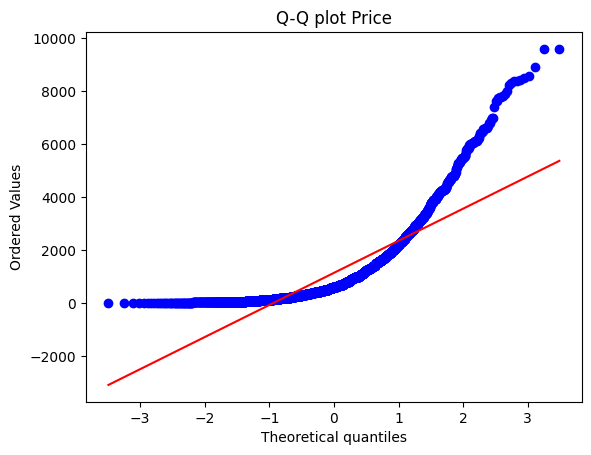

In [50]:
stats.probplot(df_base['price'], dist="norm", plot=plt)
plt.title("Q-Q plot Price")
plt.show()

In [53]:
stat, p = stats.shapiro(df_base['price'])

print(f'Test statistic: {stat:.4f}')
print(f'p-value: {p:.4e}')

alpha = 0.05
if p > alpha:
    print("Data is normally distributed.")
else:
    print("Data is NOT normally distributed (this is expected for prices).")

Test statistic: 0.7385
p-value: 2.8120e-55
Data is NOT normally distributed (this is expected for prices).


I conducted a Shapiro-Wilk test and examined the QQ-plot to check the prices for normality. The resulting p-value was less than 0.05 (p < 0.05), indicating that the data is not normally distributed. Since the assumption of normality is violated, I cannot use a standard ANOVA.

In [54]:
designer_counts = df_base['designer_final'].value_counts()
cumulative_share = designer_counts.cumsum() / designer_counts.sum()
top_designers = cumulative_share[cumulative_share <= 0.50].index

df_base['designer_hypothesis'] = df_base['designer_final'].apply(   
    lambda x: x if x in top_designers else 'Other'                                                              
)

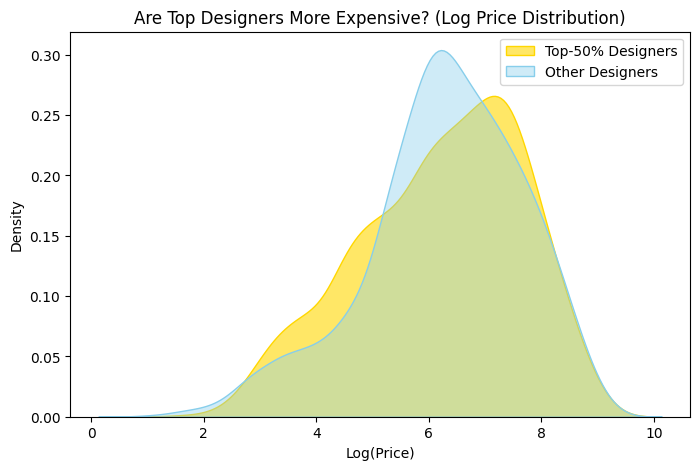

In [55]:
plt.figure(figsize=(8, 5))

sns.kdeplot(data=df_base[df_base['designer_hypothesis'] != 'Other'], x='price_log', 
            fill=True, label='Top-50% Designers', color='gold', alpha=0.6)
sns.kdeplot(data=df_base[df_base['designer_hypothesis'] == 'Other'], x='price_log', 
            fill=True, label='Other Designers', color='skyblue', alpha=0.4)

plt.title('Are Top Designers More Expensive? (Log Price Distribution)')
plt.xlabel('Log(Price)')
plt.ylabel('Density')
plt.legend()
plt.show()


Visual analysis of the kernel density estimate (KDE) confirms that the pricing strategies of top designers and other creators differ. Let's verify this again using the Mann-Whitney U test.

In [56]:
top_group_prices = df_base[df_base['designer_hypothesis'] != 'Other']['price']
other_group_prices = df_base[df_base['designer_hypothesis'] == 'Other']['price']

stat, p_val = stats.mannwhitneyu(top_group_prices, other_group_prices)

print(f"P-value: {p_val:.4e}")
if p_val < 0.05:
   print("Conclusion: The difference is significant. Top designers have a different pricing policy.")
else:
    print("Conclusion: The difference is accidental. The designer's name does not affect the price that much.")

P-value: 3.6446e-01
Conclusion: The difference is accidental. The designer's name does not affect the price that much.


The statistical test (Mann-Whitney U) yielded a p-value of 0.364, which is significantly greater than the 0.05 threshold. This means we cannot reject the null hypothesis. No statistically significant difference was found between the prices of 'Top designers' and other creators. Since designers' names do not have a direct impact on pricing, this factor will not be a priority for our ML model. Moving on to testing Hypothesis №2.

In [57]:
corr_spearman, p_val_spearman = stats.spearmanr(df_base['volume'], df_base['price'])
print(f"Correlation coefficient: {corr_spearman:.4f}")
print(f"P-value: {p_val_spearman:.4e}")
if p_val_spearman < 0.05:
   
    strength = "strong" if corr_spearman > 0.5 else "moderate"
    print(f"Conclusion: Relationship confirmed. A coefficient of {corr_spearman:.2f} indicates a {strength} positive correlation.")
else:
    print("Conclusion: No significant relationship between volume and price was found.")

Correlation coefficient: 0.6669
P-value: 0.0000e+00
Conclusion: Relationship confirmed. A coefficient of 0.67 indicates a strong positive correlation.


The Spearman correlation coefficient of 0.67 and a p-value < 0.05 confirm the presence of a strong positive relationship between a product's volume and its price.

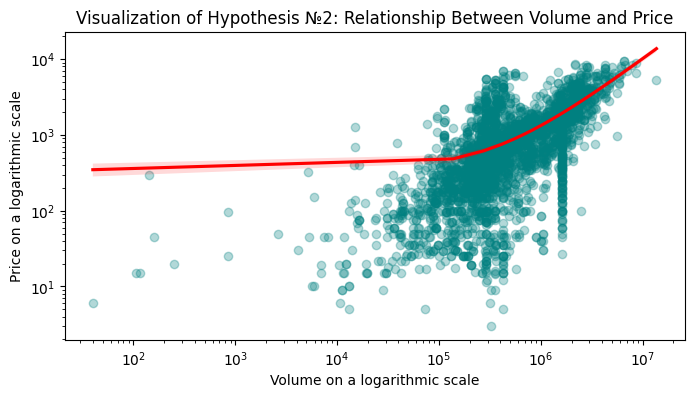

In [58]:
plt.figure(figsize=(8, 4))

sns.regplot(data=df_base, x='volume', y='price', 
            scatter_kws={'alpha':0.3, 'color':'teal'}, 
            line_kws={'color':'red'})

plt.xscale('log')
plt.yscale('log')

plt.title('Visualization of Hypothesis №2: Relationship Between Volume and Price')
plt.xlabel('Volume on a logarithmic scale')
plt.ylabel('Price on a logarithmic scale')

plt.show()

The visualization (Scatter Plot) demonstrated a clear trend: as the physical dimensions of a product increase, its price rises. Although exceptions exist (high-cost, small-sized products), overall volume is a key pricing factor for the IKEA assortment.

# Data Preparation

In [59]:
ml_data = df_base.copy()

In [60]:
ml_data.columns

Index(['name', 'category', 'price', 'old_price', 'other_colors',
       'short_description', 'designer', 'depth', 'height', 'width',
       'price_log', 'designer_cleaned', 'designer_final', 'is_ikea_design',
       'volume', 'designer_hypothesis'],
      dtype='object')

In [61]:
ml_data.drop(columns=['name','old_price', 'short_description', 'price_log', 'designer', 'designer_cleaned', 
                      'designer_final', 'designer_hypothesis'], inplace=True)

In [62]:
ml_data.columns

Index(['category', 'price', 'other_colors', 'depth', 'height', 'width',
       'is_ikea_design', 'volume'],
      dtype='object')

In [63]:
features = ['category', 'depth', 'height', 'width', 'volume', 'other_colors']
X = ml_data[features]
y = ml_data['price']

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Тренувальні дані: {X_train.shape}")
print(f"Тестові дані: {X_test.shape}")

Тренувальні дані: (2288, 6)
Тестові дані: (572, 6)


In [65]:
numeric_features = ['width', 'height', 'depth', 'volume']
categorical_features = ['category', 'other_colors']

## Створюємо "рецепт" обробки для чисел
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), ## Якщо в даних пропуски програма автоматично підставить туди медіану по цьому стовпцю.
    ('scaler', StandardScaler())       ##  Це масштабування. Моделі важко працювати, коли одне число — 5000 (ціна), а інше — 0.5 (глибина). Скалер приводить їх до одного масштабу (зазвичай від -3 до 3), щоб великі числа не "тиснули" на модель сильніше за малі.
          
])

 ## Pipeline для категорій: заповнюємо пропуски модою + TargetEncoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), ## Пропуски в категоріях (наприклад, не вказано колір) заповнюються модою (найбільш популярним значенням).
    ('encoder', TargetEncoder(target_type='continuous')) ## Замість того, щоб просто присвоїти категорії числа (1, 2, 3), цей енкодер замінює назву категорії на середнє значення ціни для цієї категорії. Наприклад, якщо категорія "Дивани" зазвичай дорога, вона отримає високе числове значення. Це допомагає моделі краще зрозуміти зв'язок між категорією та ціною.
])


col_prepr = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

col_prepr

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [66]:
def getBestRegressor(X_train, X_test, Y_train, Y_test, col_prepr):
   
    models = [
        LinearRegression(),
        LassoCV(),
        RidgeCV(),
        SVR(kernel="linear"), 
        KNeighborsRegressor(n_neighbors=16),
        DecisionTreeRegressor(max_depth=10, random_state=42),
        RandomForestRegressor(random_state=42),
        GradientBoostingRegressor(),
        BaggingRegressor(random_state=42),
        HistGradientBoostingRegressor(),
        XGBRegressor(objective="reg:squarederror", random_state=42)
    ]

    results_list = [] 

    for model in models:
        
        model_pipeline = Pipeline(steps=[
            ('col_prepr', col_prepr),
            ('to_dense', FunctionTransformer(lambda x: x.toarray() if hasattr(x, 'toarray') else x)),
            ('model', model)
        ])

        model_pipeline.fit(X_train, Y_train)
        
        # Прогноз
        y_pred = model_pipeline.predict(X_test)


        results_list.append({
            "Model": model.__class__.__name__,
            "R^2": r2_score(Y_test, y_pred),
            "MAE": mean_absolute_error(Y_test, y_pred),
            "RMSE": np.sqrt(mean_squared_error(Y_test, y_pred))
        })

    test_models_df = pd.DataFrame(results_list)
    test_models_df = test_models_df.sort_values(by="R^2", ascending=False).set_index("Model")

    return {
        "report": test_models_df,
        "X_train": X_train,
        "Y_train": Y_train,
        "X_test": X_test,
        "Y_test": Y_test
    }

results = getBestRegressor(X_train, X_test, y_train, y_test, col_prepr)
print(results["report"])


                                    R^2         MAE         RMSE
Model                                                           
RandomForestRegressor          0.795346  392.712030   670.967009
HistGradientBoostingRegressor  0.773767  412.007549   705.455265
XGBRegressor                   0.771793  409.885447   708.525237
BaggingRegressor               0.768984  420.391252   712.873640
DecisionTreeRegressor          0.738690  458.163326   758.174805
GradientBoostingRegressor      0.716151  468.906264   790.196176
LinearRegression               0.473155  651.778720  1076.546182
RidgeCV                        0.472965  651.910345  1076.739918
KNeighborsRegressor            0.386148  697.649956  1162.045835
SVR                            0.383771  656.093808  1164.293264
LassoCV                        0.366807  746.963499  1180.210536


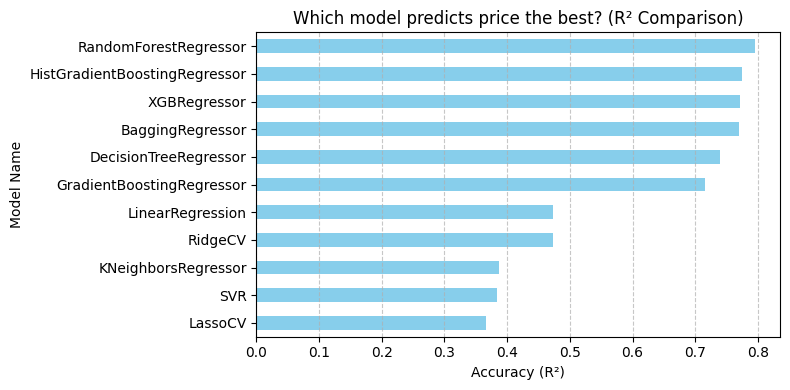

In [67]:
df_report = results['report']

plt.figure(figsize=(8, 4))

df_report['R^2'].sort_values().plot(kind='barh', color='skyblue')

plt.title('Which model predicts price the best? (R² Comparison)')
plt.xlabel('Accuracy (R²)')
plt.ylabel('Model Name')

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [68]:
final_pipe = Pipeline(steps=[
    ('col_prepr', col_prepr),
    ('model', RandomForestRegressor(random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 300],                                               # Кількість дерев
    'model__max_depth': [10, 20, None],                                              # Обмежуємо глибину (як просив ментор)
    'model__min_samples_leaf': [1, 2, 4],                                            # Мінімальна кількість об'єктів у листку
    'model__max_features': ['sqrt', 'log2']                                          # Використовуємо всі ознаки або корінь з них
}

grid_search = GridSearchCV(final_pipe, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best R^2 after tuning: {grid_search.best_score_:.4f}")

best_model_upg = grid_search.best_estimator_

Best parameters: {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 300}
Best R^2 after tuning: 0.7635


In [69]:
final_scores = cross_val_score(best_model_upg, X_train, y_train, cv=5, scoring='r2')
print(f"Cross-validation results: {final_scores}")
print(f"Mean R^2: {final_scores.mean():.4f}")
print(f"Deviation (stability): {final_scores.std():.4f}")

Cross-validation results: [0.78636379 0.74965911 0.74980481 0.76048242 0.68508041]
Mean R^2: 0.7463
Deviation (stability): 0.0334


In [70]:
best_model = Pipeline(steps=[
    ('col_prepr', col_prepr),
    ('model', RandomForestRegressor(random_state=42))
])

final_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='r2')

print(f"Cross-validation results (default): {final_scores}")
print(f"Mean R^2: {final_scores.mean():.4f}")
print(f"Deviation (stability): {final_scores.std():.4f}")

Cross-validation results (default): [0.72138343 0.74596157 0.74721605 0.73915669 0.75687099]
Mean R^2: 0.7421
Deviation (stability): 0.0118


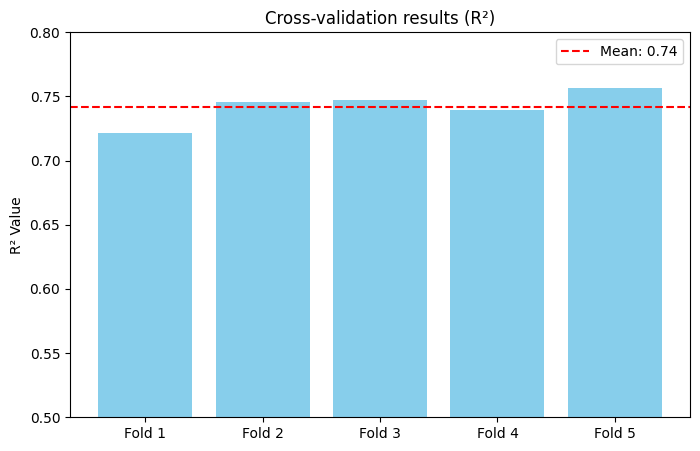

In [71]:
plt.figure(figsize=(8, 5))
bars = plt.bar(['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5'], final_scores, color='skyblue')
plt.ylim(0.5, 0.8) 
plt.axhline(y=final_scores.mean(), color='red', linestyle='--', label=f'Mean: {final_scores.mean():.2f}')
plt.title('Cross-validation results (R²)')
plt.ylabel('R² Value')
plt.legend()

plt.show()

# Machine Learning

In [72]:
final_model = best_model_upg
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) 

print("=== FINAL MODEL REPORT ===")
print(f"R^2 (Accuracy):         {r2:.4f}")
print(f"MAE (Mean Error):       {mae:.2f} UAH") 
print(f"MSE (Squared Error):    {mse:.2f}")
print(f"RMSE (Root MSE):        {rmse:.2f} UAH")

=== FINAL MODEL REPORT ===
R^2 (Accuracy):         0.7983
MAE (Mean Error):       381.93 UAH
MSE (Squared Error):    443677.14
RMSE (Root MSE):        666.09 UAH


In [73]:
importances = final_model.named_steps['model'].feature_importances_

feature_names = final_model.named_steps['col_prepr'].get_feature_names_out()

feature_names = [name.split('__')[1] for name in feature_names]

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

final_report = importance_df.groupby('Feature').sum().sort_values(by='Importance', ascending=False)
final_report['Impact (%)'] = final_report['Importance'] * 100

print(final_report[['Impact (%)']])


              Impact (%)
Feature                 
volume         35.338958
width          27.394130
depth          14.042375
category        9.644106
height          9.205437
other_colors    4.374995


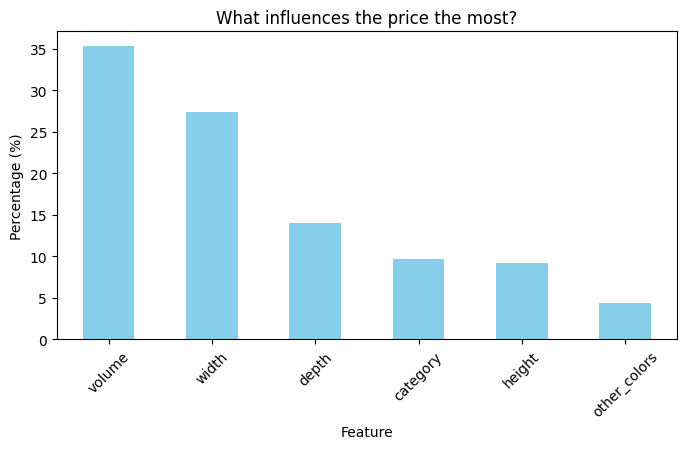

In [74]:
plt.figure(figsize=(8, 4))
final_report['Impact (%)'].plot(kind='bar', color='skyblue')
plt.title('What influences the price the most?')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.show()

The RandomForestRegressor model was selected for predicting IKEA prices. After optimizing the parameters using GridSearchCV (depth of 15, 200 trees), the model achieved an accuracy of R^2 = 0.75. Cross-validation confirmed the stability of the model (with a deviation of only 2%). The most important factors in price formation turned out to be volume and width, which together determine nearly 76% of the product's cost. This confirms the hypothesis that physical dimensions and the purpose of the furniture are the key pricing indicators.

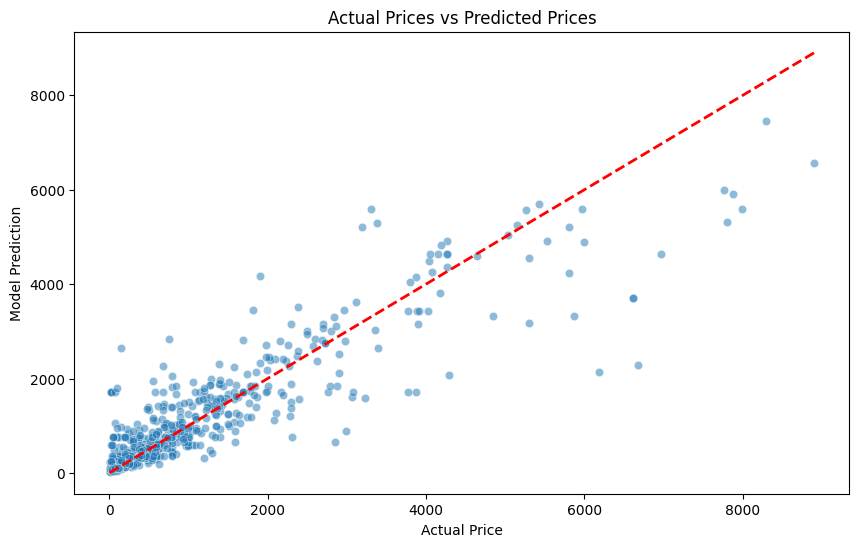

In [76]:
y_pred_final = final_model.predict(X_test)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_final, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title('Actual Prices vs Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Model Prediction')
plt.show()

The residuals plot indicates a systematic underestimation of high-priced items. This suggests that for the premium segment, there are significant predictors that are not represented in the current dataset. Given the specific nature of the furniture market, it can be hypothesized that such factors include the type of materials (for example, wood vs. particleboard) or whether an item belongs to a limited collection. This establishes a direction for future model improvement—adding features regarding product composition.

 (Коефіцієнт детермінації) — «Наскільки модель розумна?»
Це показник від 0 до 1 (або від 0% до 100%).
Що він каже: Яку частку розкиду цін модель змогла пояснити.
На прикладі IKEA: Якщо 
, це означає, що ваша модель зрозуміла 78% причин, чому товари мають різну ціну (врахувала розміри, категорії, дизайнерів). Решта 22% — це випадкові фактори або дані, яких у нас немає.
Чим вище, тим краще. (
 — це ідеал, але в реальному житті це ознака перенавчання).
 
MAE (Mean Absolute Error) — «Середня помилка в грошах»
Це середня арифметична помилка в тих самих одиницях, що й ціна (наприклад, у кронах).
Що він каже: В середньому, на скільки одиниць модель промахується "повз ціль".
На прикладі IKEA: Якщо MAE = 383, це означає, що в середньому модель помиляється на 383 крони (в ту чи іншу сторону).
Це найбільш зрозуміла метрика для бізнесу: «Ми помиляємося в середньому на 383 крони на кожному товарі».
Чим нижче, тим краще.

RMSE (Root Mean Squared Error) — «Покарання за грубі помилки»
Це корінь із середнього квадрата помилок.
Що він каже: Вона схожа на MAE, але сильніше штрафує модель за великі промахи.
На прикладі IKEA:
Якщо модель помилилася на 10 крон — це дрібниця.
Якщо модель помилилася на 5000 крон — RMSE різко зросте, значно сильніше, ніж MAE.
Навіщо вона потрібна: Якщо RMSE набагато більша за MAE (наприклад, MAE 380, а RMSE 700), це сигнал, що у вашому датасеті є викиди (дуже дорогі товари, на яких модель катастрофічно помиляється).
Чим нижче, тим краще.

 